# Tag 10 — Anfänger
## XGBoost Classifier — Bank Marketing

In [1]:

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_DIR = Path(r"C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_10_Boosting_Project")
if not PROJECT_DIR.exists():
    PROJECT_DIR = Path.cwd()
    while PROJECT_DIR.name not in ["Tag_10_Boosting_Project", ""] and PROJECT_DIR.parent != PROJECT_DIR:
        PROJECT_DIR = PROJECT_DIR.parent
DATA_DIR = PROJECT_DIR / "data" / "raw"
OUTPUT_DIR = PROJECT_DIR / "outputs" / "01_anfaenger"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_DIR:", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)


PROJECT_DIR: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_10_Boosting_Project
DATA_DIR: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_10_Boosting_Project\data\raw
OUTPUT_DIR: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_10_Boosting_Project\outputs\01_anfaenger


In [2]:

import sys
import subprocess

print("Installing xgboost into:", sys.executable)
subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost"])


Installing xgboost into: c:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\.venv\Scripts\python.exe


0

In [3]:

BANK_PATH = DATA_DIR / "bank.csv"
if not BANK_PATH.exists():
    raise FileNotFoundError(f"bank.csv not found in: {DATA_DIR}")

try:
    df = pd.read_csv(BANK_PATH, sep=';')
    if df.shape[1] == 1:
        df = pd.read_csv(BANK_PATH)
except Exception:
    df = pd.read_csv(BANK_PATH)

df.columns = df.columns.str.strip()
print(df.shape)
display(df.head())
print(df.columns.tolist())


(11162, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']


In [4]:

possible_targets = ["y", "deposit", "subscribed", "target"]
target_col = next((c for c in possible_targets if c in df.columns), None)
if target_col is None:
    raise ValueError(f"No known target column found. Available columns: {df.columns.tolist()}")

y_raw = df[target_col]
X = df.drop(columns=[target_col])

if pd.api.types.is_object_dtype(y_raw.dtype) or pd.api.types.is_string_dtype(y_raw.dtype) or pd.api.types.is_categorical_dtype(y_raw.dtype):
    y = y_raw.astype(str).str.strip().str.lower().map({"yes":1, "no":0, "true":1, "false":0})
    if y.isna().any():
        y = pd.factorize(y_raw)[0]
    else:
        y = y.astype(int)
else:
    y = y_raw

print("Target:", target_col)
print(pd.Series(y).value_counts())


Target: deposit
deposit
0    5873
1    5289
Name: count, dtype: int64


In [5]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(X_train.shape, X_test.shape)


(8929, 16) (2233, 16)


In [6]:

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Numeric:", numeric_features)
print("Categorical:", categorical_features)


Numeric: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Categorical: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


C:\Users\esmae\AppData\Local\Temp\ipykernel_20392\1222476664.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()


In [7]:
import xgboost
print("xgboost OK ✅")
print(xgboost.__version__)

xgboost OK ✅
3.2.0


In [8]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

try:
    from xgboost import XGBClassifier
except ModuleNotFoundError as e:
    raise ModuleNotFoundError("Please install xgboost: pip install xgboost") from e

rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=1, class_weight="balanced"))
])

xgb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.1,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        eval_metric="logloss",
        n_jobs=1
    ))
])

models = {"RandomForest": rf_pipe, "XGBoost": xgb_pipe}
results = []
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "f1": f1_score(y_test, pred, average="weighted")
    })
    print("\n", name)
    print(classification_report(y_test, pred))

results_df = pd.DataFrame(results).sort_values("f1", ascending=False)
display(results_df)
results_df.to_csv(OUTPUT_DIR / "beginner_xgboost_vs_randomforest.csv", index=False)



 RandomForest
              precision    recall  f1-score   support

           0       0.88      0.83      0.85      1175
           1       0.82      0.87      0.85      1058

    accuracy                           0.85      2233
   macro avg       0.85      0.85      0.85      2233
weighted avg       0.85      0.85      0.85      2233


 XGBoost
              precision    recall  f1-score   support

           0       0.88      0.84      0.86      1175
           1       0.83      0.87      0.85      1058

    accuracy                           0.85      2233
   macro avg       0.85      0.86      0.85      2233
weighted avg       0.86      0.85      0.85      2233



,model,accuracy,f1
1,XGBoost,0.854456,0.854555
0,RandomForest,0.848634,0.848736


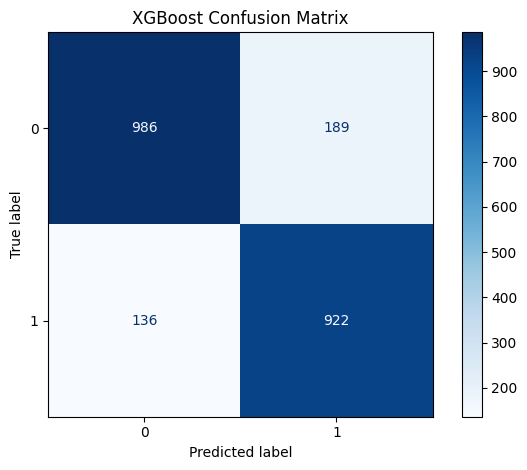

In [9]:

y_pred_xgb = xgb_pipe.predict(X_test)
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
disp.plot(cmap="Blues")
plt.title("XGBoost Confusion Matrix")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "beginner_xgboost_confusion_matrix.png", dpi=200)
plt.show()


,feature,importance
11,housing,0.181797
3,duration,0.170595
13,contact,0.133590
15,poutcome,0.088073
6,previous,0.074753
12,loan,0.062485
5,pdays,0.057333
14,month,0.048017
0,age,0.034697
9,education,0.028708


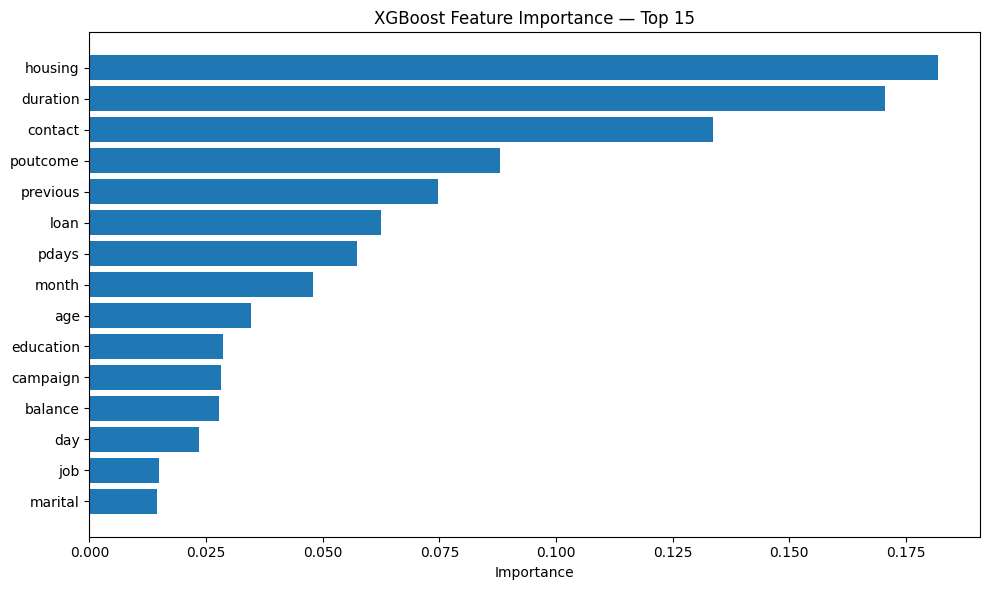

In [10]:

feature_names = numeric_features + categorical_features
xgb_model = xgb_pipe.named_steps["model"]
importances = pd.DataFrame({
    "feature": feature_names,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

display(importances.head(15))
importances.to_csv(OUTPUT_DIR / "beginner_xgboost_feature_importance.csv", index=False)

plt.figure(figsize=(10, 6))
plt.barh(importances.head(15)["feature"][::-1], importances.head(15)["importance"][::-1])
plt.xlabel("Importance")
plt.title("XGBoost Feature Importance — Top 15")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "beginner_xgboost_feature_importance.png", dpi=200)
plt.show()
